In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [3]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [4]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [5]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [6]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

### Train

In [7]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [8]:
train_box(box_model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 50 concetti unici e 583 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.4812
Epoca [10/100] | Loss: 0.1834
Epoca [20/100] | Loss: 0.0574
Epoca [30/100] | Loss: 0.0204
Epoca [40/100] | Loss: 0.0096
Epoca [50/100] | Loss: 0.0059
Epoca [60/100] | Loss: 0.0042
Epoca [70/100] | Loss: 0.0034
Epoca [80/100] | Loss: 0.0031
Epoca [90/100] | Loss: 0.0028
Epoca [100/100] | Loss: 0.0026

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: lower_body_part | big
 - P_teorica: 0.0 -> P_predetta: 0.0035
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


### Visualization

In [9]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

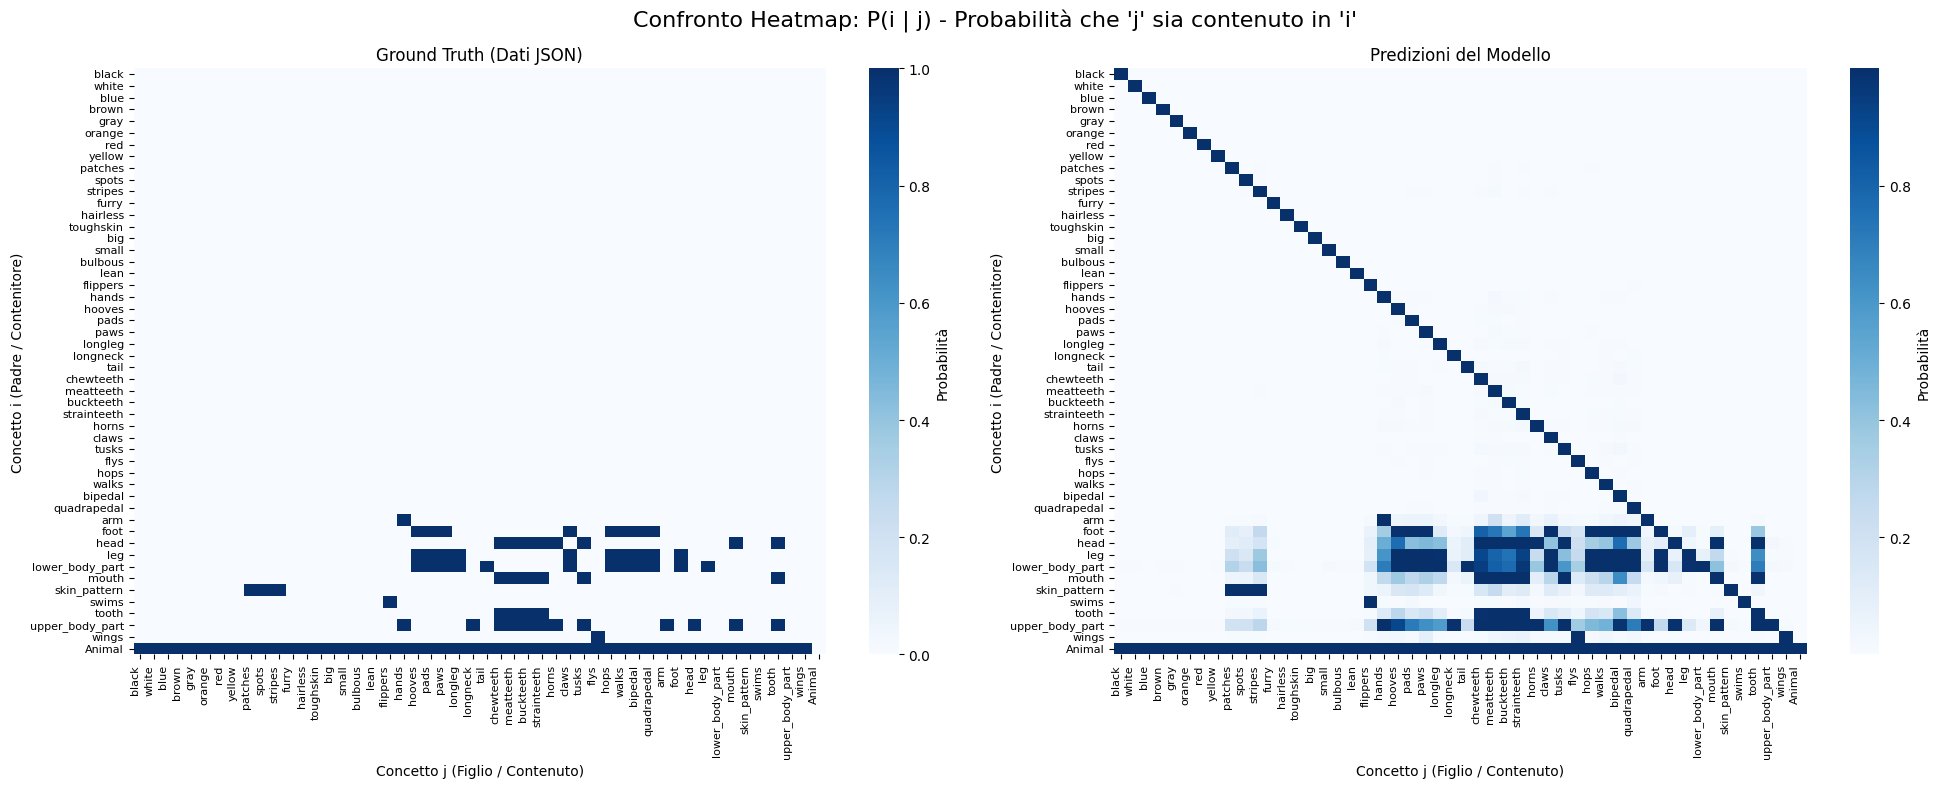

In [10]:
visualize_heatmap_compare(box_model, dataset, concept2id, id2concept)

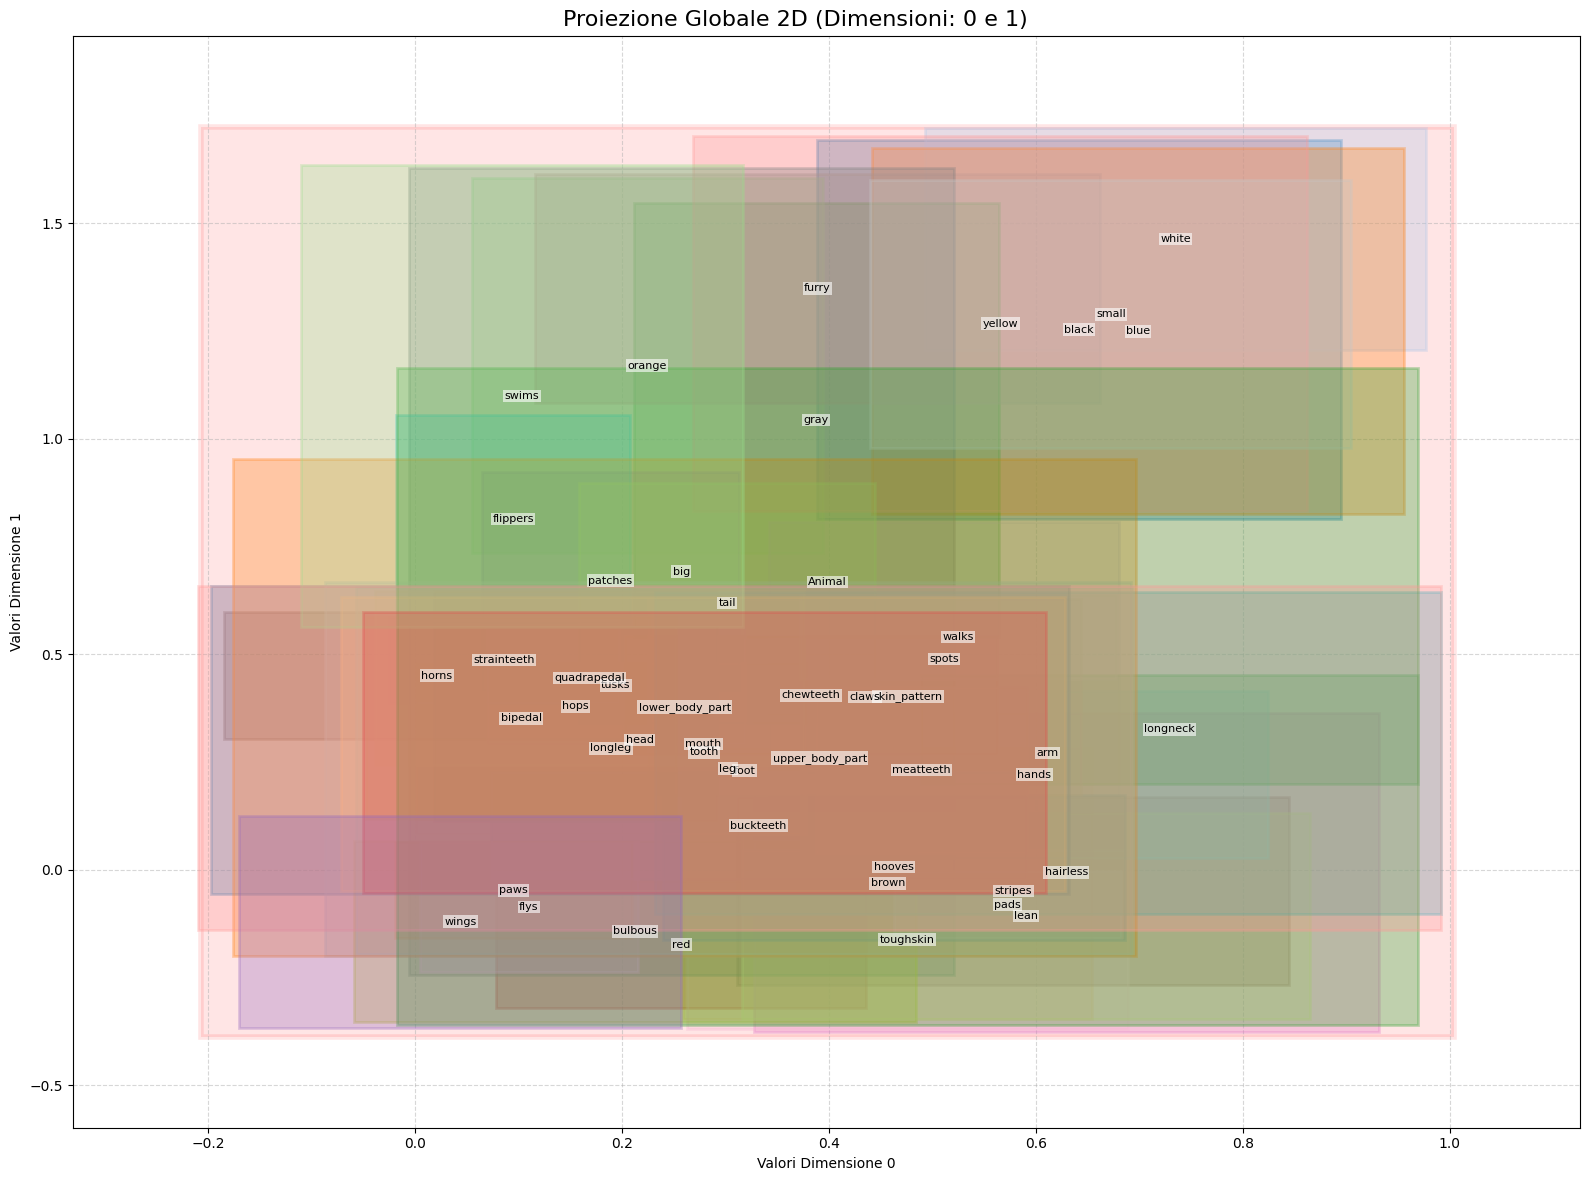

In [11]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

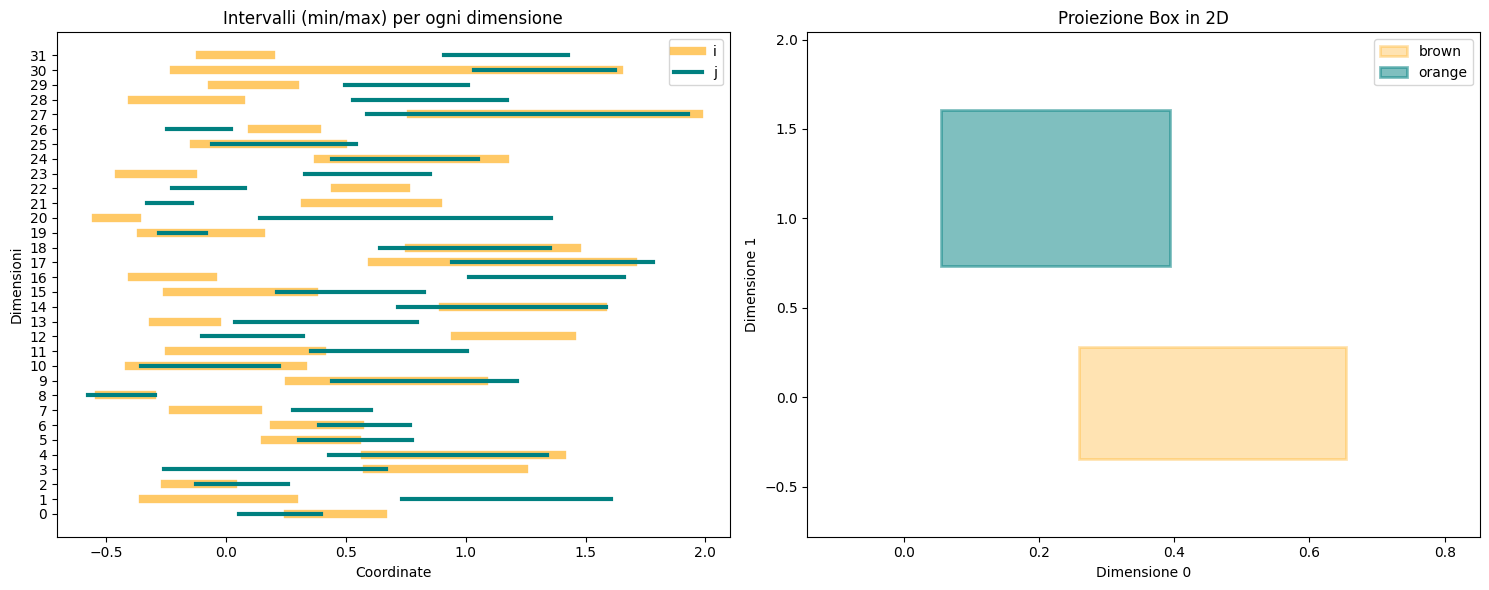

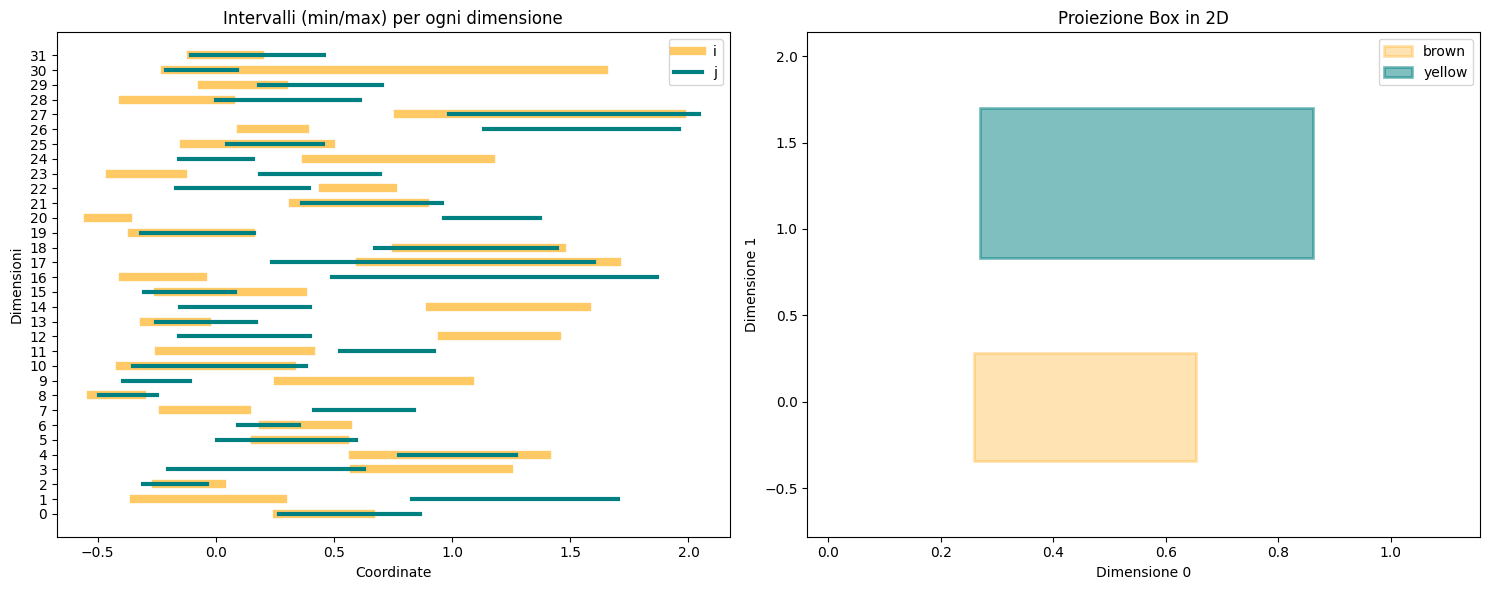

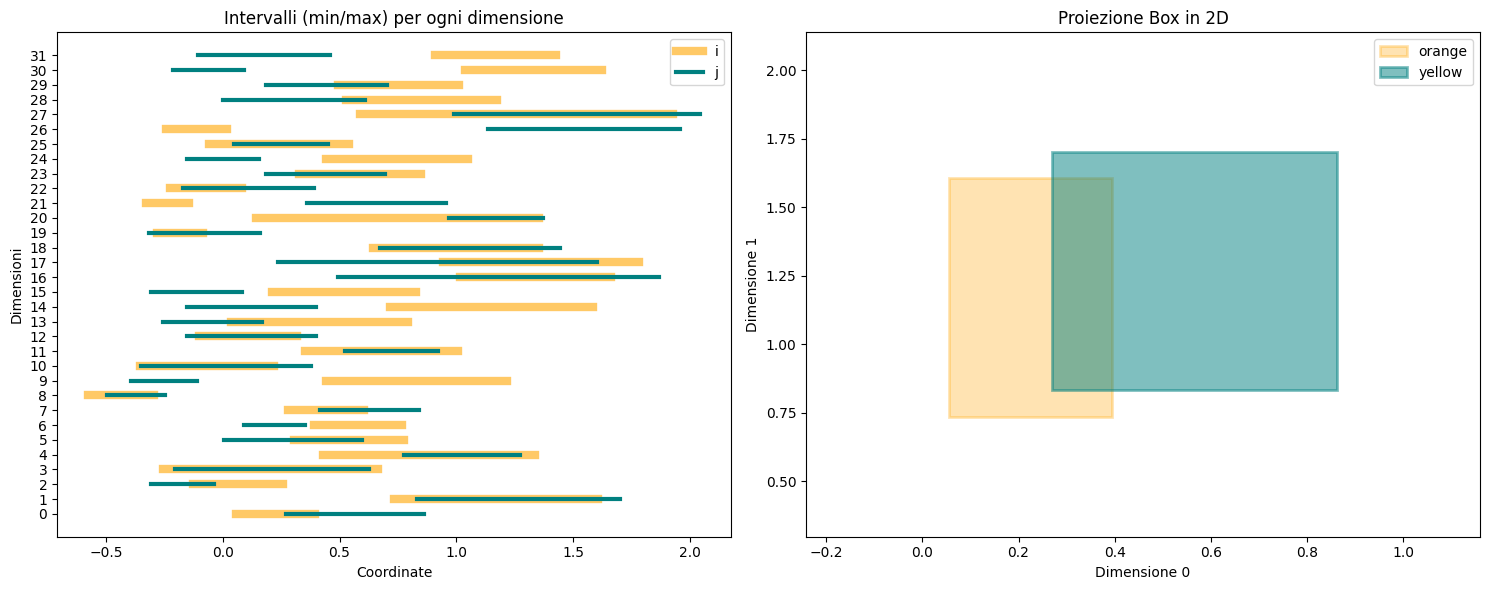

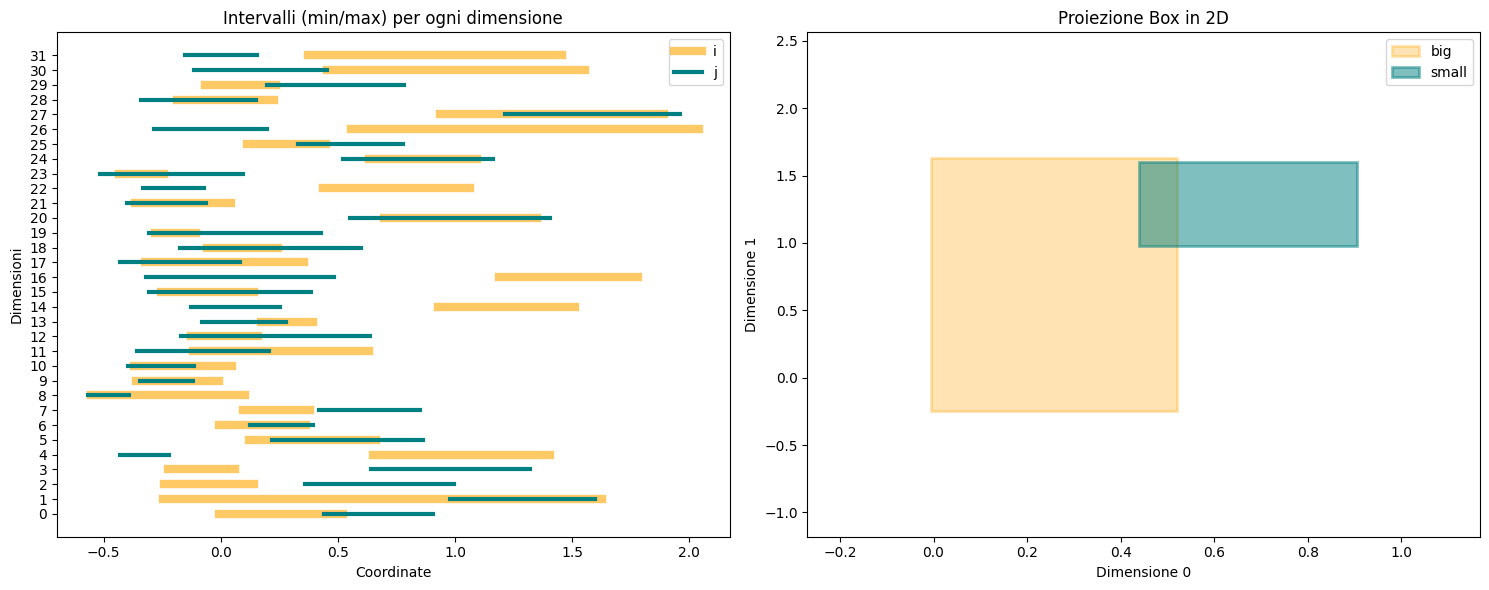

In [12]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "orange")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "orange", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "big", "small")

### Save boxes

In [13]:
from src.CHM.model import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

In [14]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[1.0045, 1.7231, 1.1192, 1.3872, 1.4232, 0.9403, 0.9683, 0.8890, 1.1328,
         1.2204, 1.1816, 1.0833, 1.5548, 0.9685, 1.6693, 1.1410, 1.8921, 1.8101,
         1.5400, 1.2972, 1.5010, 1.2450, 1.1765, 1.1278, 1.1744, 1.0663, 2.0542,
         2.0776, 1.2245, 1.1324, 1.7535, 1.5863]])
Coordinate z (min) per 'wings': tensor([[-0.1696, -0.3668,  0.1754, -0.2311, -0.0395,  0.1362, -0.2885, -0.1719,
         -0.5532, -0.3358, -0.4071, -0.0431,  0.6643, -0.0316,  0.2674,  0.1523,
          0.0181,  0.0441,  0.5037,  0.3332,  0.1252, -0.2164, -0.3195, -0.4935,
         -0.0202, -0.0716,  0.5814, -0.2487,  0.4289,  0.2898, -0.2042,  0.1971]])


## CBM

### Load dataset

In [15]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [16]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [17]:
box_dict = get_box_dict(box_model, id2concept)

In [18]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[1.0045, 1.7231, 1.1192, 1.3872, 1.4232, 0.9403, 0.9683, 0.8890, 1.1328,
         1.2204, 1.1816, 1.0833, 1.5548, 0.9685, 1.6693, 1.1410, 1.8921, 1.8101,
         1.5400, 1.2972, 1.5010, 1.2450, 1.1765, 1.1278, 1.1744, 1.0663, 2.0542,
         2.0776, 1.2245, 1.1324, 1.7535, 1.5863]])
Coordinate z (min) per 'wings': tensor([[-0.1696, -0.3668,  0.1754, -0.2311, -0.0395,  0.1362, -0.2885, -0.1719,
         -0.5532, -0.3358, -0.4071, -0.0431,  0.6643, -0.0316,  0.2674,  0.1523,
          0.0181,  0.0441,  0.5037,  0.3332,  0.1252, -0.2164, -0.3195, -0.4935,
         -0.0202, -0.0716,  0.5814, -0.2487,  0.4289,  0.2898, -0.2042,  0.1971]])


In [19]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.CHM.model import prepara_tensore_box

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [20]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier
import matplotlib.pyplot as plt
from src.CHM.test import test_cbm_classifier, plot_test_results

### CBM with boxes

#### Train

In [21]:
b_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(b_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

info = "boxes"

b_history = train_cbm_classifier(
    b_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=0.083, Acc=98.8% | VAL: Loss=0.003, Acc=100.0%
Epoca   3/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   4/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   5/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   6/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   7/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   8/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   9/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  10/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  11/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  12/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  13/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  14/20 | TRAIN: Loss=0.000, Acc=100.0% | VA

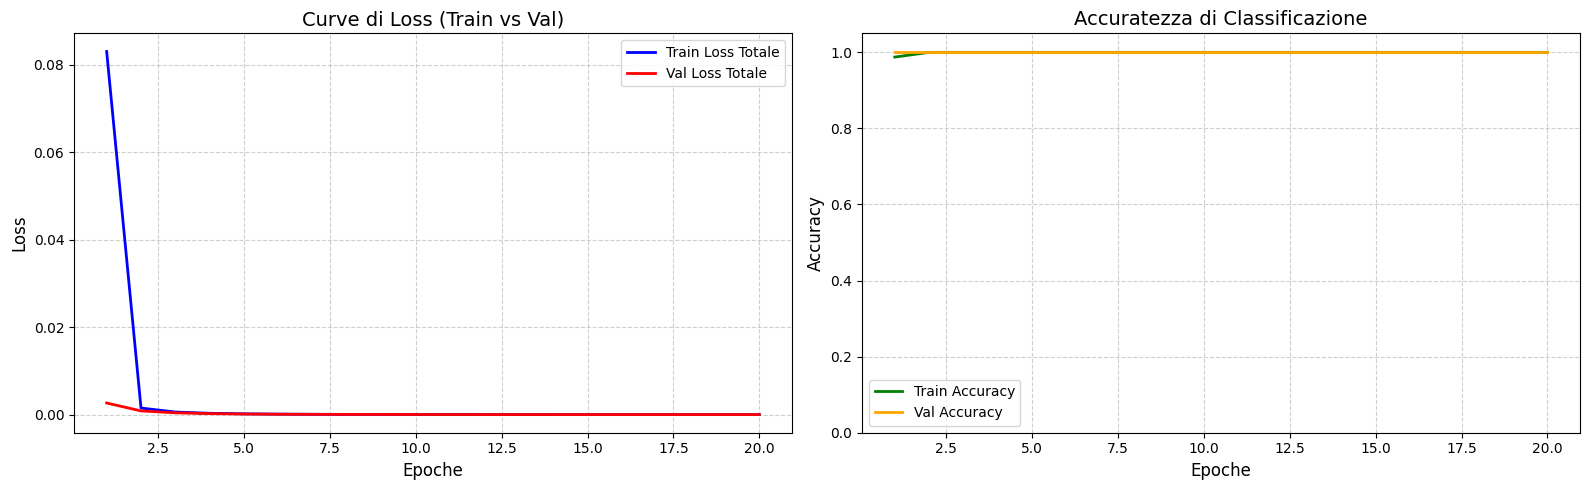

In [22]:
from src.CHM.train import plot_history
plot_history(b_history)

#### Test

In [23]:
accuracy, preds, labels = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu"
)

Inizio valutazione sul Test Set...

Risultati Test Set:
Accuratezza Totale: 100.00% (7465/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       209
           1       1.00      1.00      1.00       170
           2       1.00      1.00      1.00        58
           3       1.00      1.00      1.00        38
           4       1.00      1.00      1.00       110
           5       1.00      1.00      1.00       149
           6       1.00      1.00      1.00       329
           7       1.00      1.00      1.00       207
           8       1.00      1.00      1.00        35
           9       1.00      1.00      1.00       100

   micro avg       1.00      1.00      1.00      1405
   macro avg       1.00      1.00      1.00      1405
weighted avg       1.00      1.00      1.00      1405



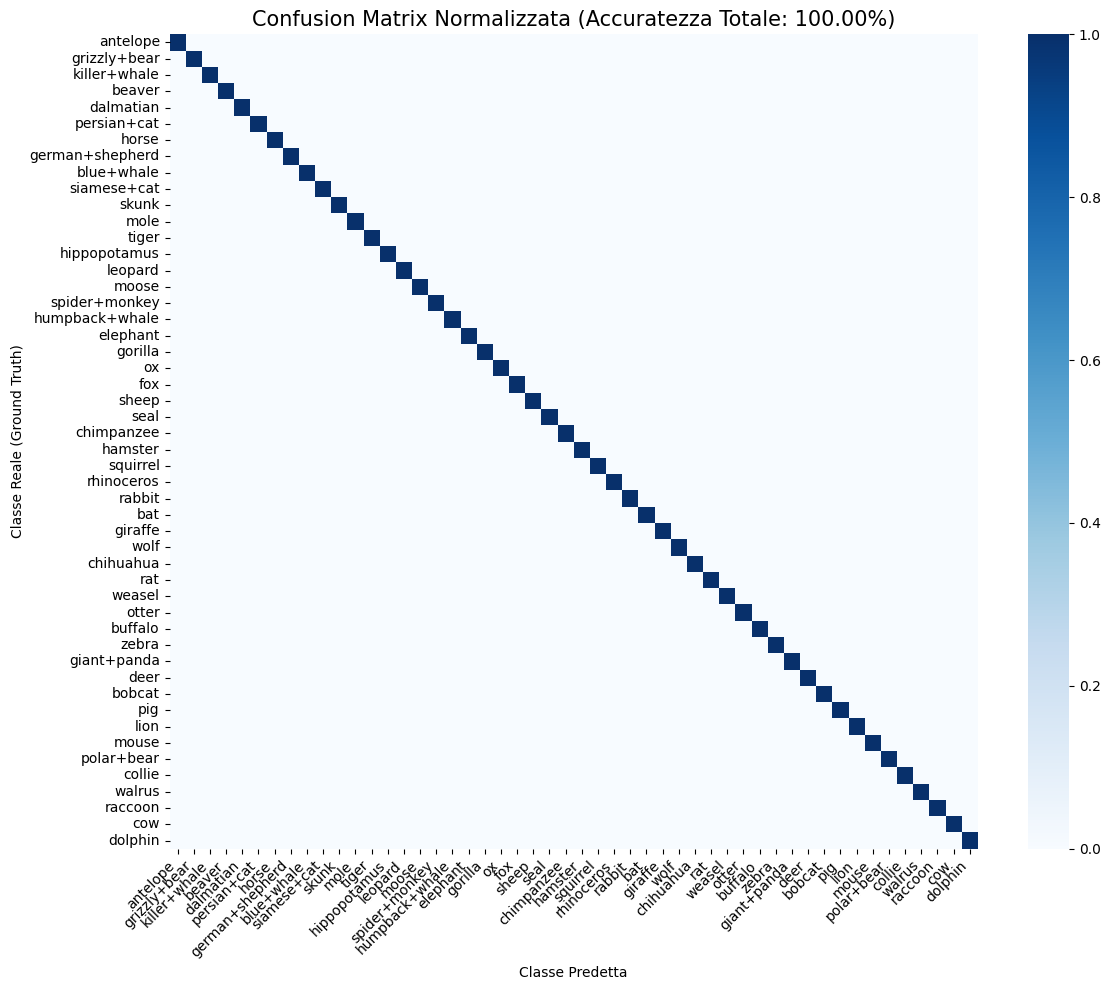


Analisi degli Errori Principali:


In [24]:
plot_test_results(accuracy, preds, labels, class_names=classes)

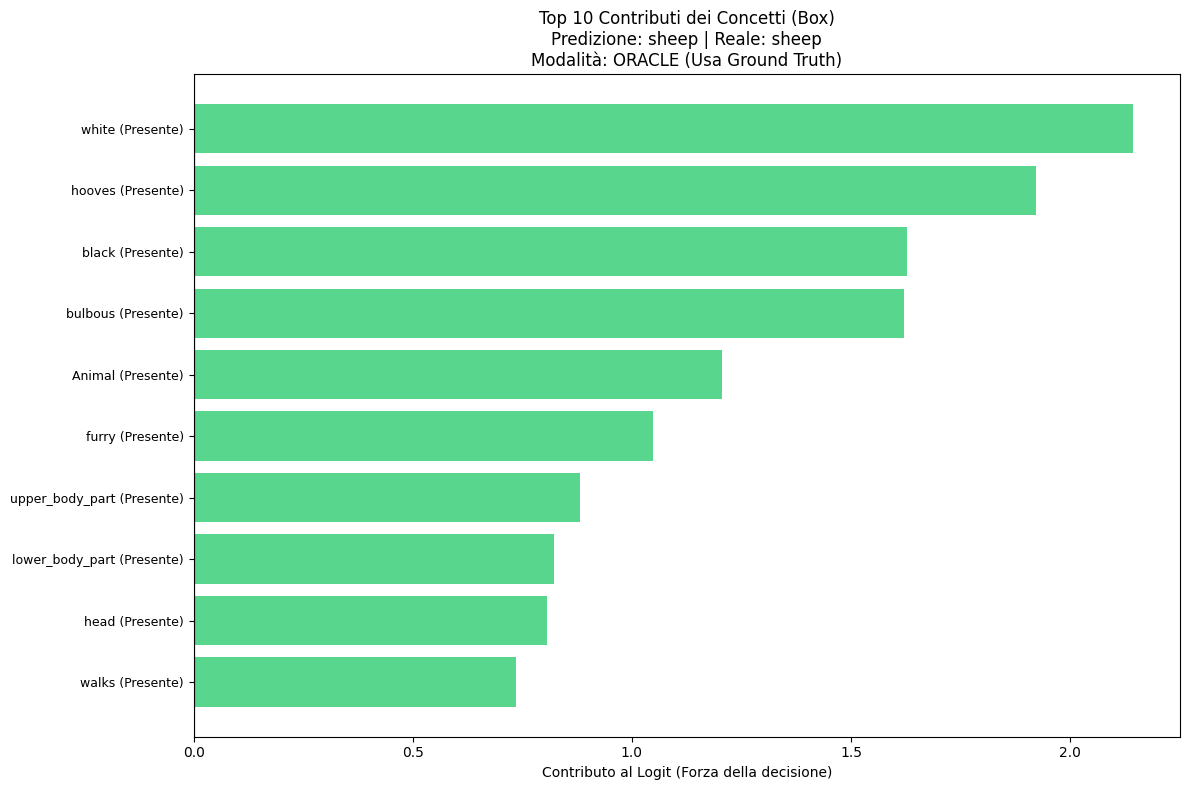

True

In [25]:
from src.CHM.interpretation import explain_prediction

explain_prediction(b_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors)

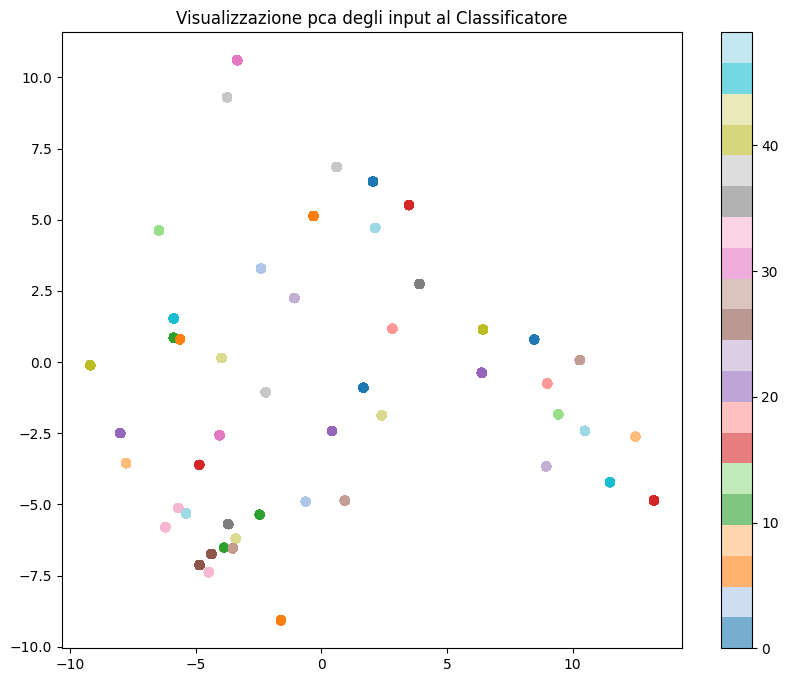

In [26]:
from src.CHM.interpretation import visualizza_separabilita, shuffle_test

visualizza_separabilita(
    model=b_model,
    test_dataloader=test_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    projection_method='pca'
)

### CBM with cond prob distrib

#### Train

In [27]:
info = "rel_matrix"
bipolar = True
cp_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(cp_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
cp_history = train_cbm_classifier(
    cp_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info,
    bipolar=bipolar
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=2.653, Acc=30.9% | VAL: Loss=2.199, Acc=49.9%
Epoca   3/20 | TRAIN: Loss=1.965, Acc=56.8% | VAL: Loss=1.773, Acc=48.3%
Epoca   4/20 | TRAIN: Loss=1.604, Acc=68.8% | VAL: Loss=1.483, Acc=68.7%
Epoca   5/20 | TRAIN: Loss=1.343, Acc=75.5% | VAL: Loss=1.227, Acc=81.1%
Epoca   6/20 | TRAIN: Loss=1.138, Acc=80.3% | VAL: Loss=1.053, Acc=79.2%
Epoca   7/20 | TRAIN: Loss=0.979, Acc=83.9% | VAL: Loss=0.908, Acc=87.2%
Epoca   8/20 | TRAIN: Loss=0.848, Acc=87.0% | VAL: Loss=0.777, Acc=90.1%
Epoca   9/20 | TRAIN: Loss=0.741, Acc=88.5% | VAL: Loss=0.692, Acc=95.6%
Epoca  10/20 | TRAIN: Loss=0.653, Acc=90.5% | VAL: Loss=0.615, Acc=92.4%
Epoca  11/20 | TRAIN: Loss=0.580, Acc=91.4% | VAL: Loss=0.544, Acc=94.1%
Epoca  12/20 | TRAIN: Loss=0.520, Acc=91.6% | VAL: Loss=0.485, Acc=91.3%
Epoca  13/20 | TRAIN: Loss=0.467, Acc=93.1% | VAL: Loss=0.435, Acc=92.3%
Epoca  14/20 | TRAIN: Loss=0.422, Acc=93.5% | VAL: Loss=0.399, Acc=92.8%

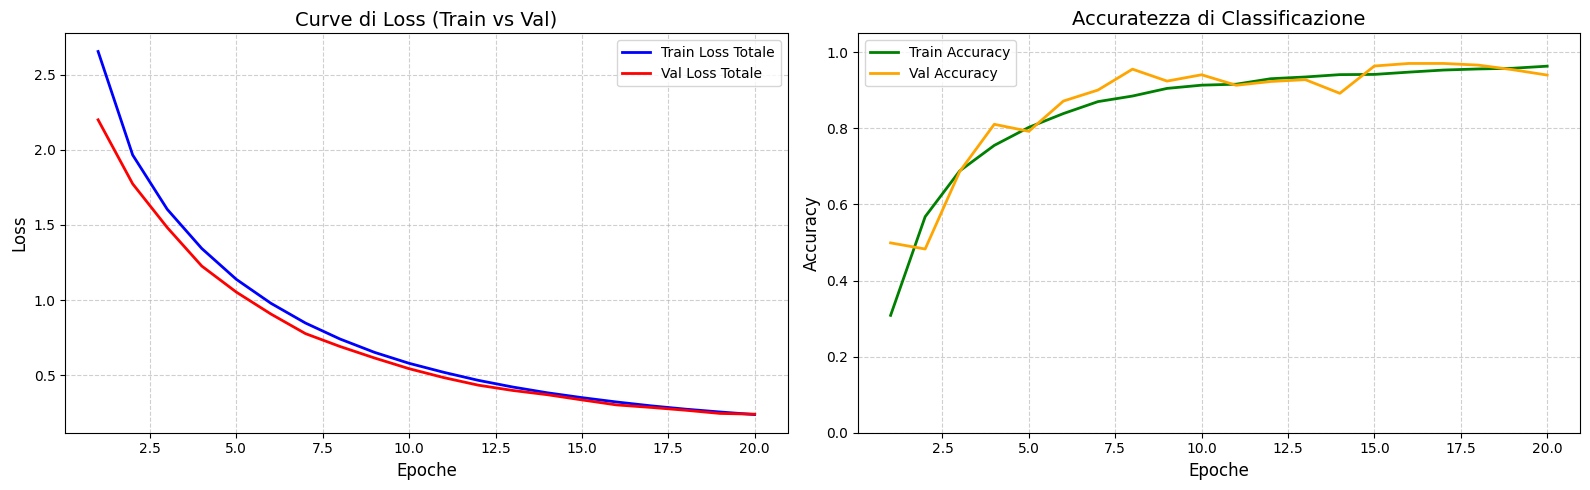

In [28]:
from src.CHM.train import plot_history
plot_history(cp_history)

#### Test

In [29]:
accuracy, preds, labels = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=bipolar,
     oracle=True,
)

Inizio valutazione sul Test Set...

Risultati Test Set:
Accuratezza Totale: 94.03% (7019/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       209
           1       0.49      1.00      0.66       170
           2       1.00      1.00      1.00        58
           3       1.00      1.00      1.00        38
           4       1.00      1.00      1.00       110
           5       1.00      1.00      1.00       149
           6       1.00      1.00      1.00       329
           7       0.67      1.00      0.81       207
           8       1.00      1.00      1.00        35
           9       0.00      0.00      0.00       100

   micro avg       0.83      0.93      0.87      1405
   macro avg       0.82      0.90      0.85      1405
weighted avg       0.82      0.93      0.86      1405



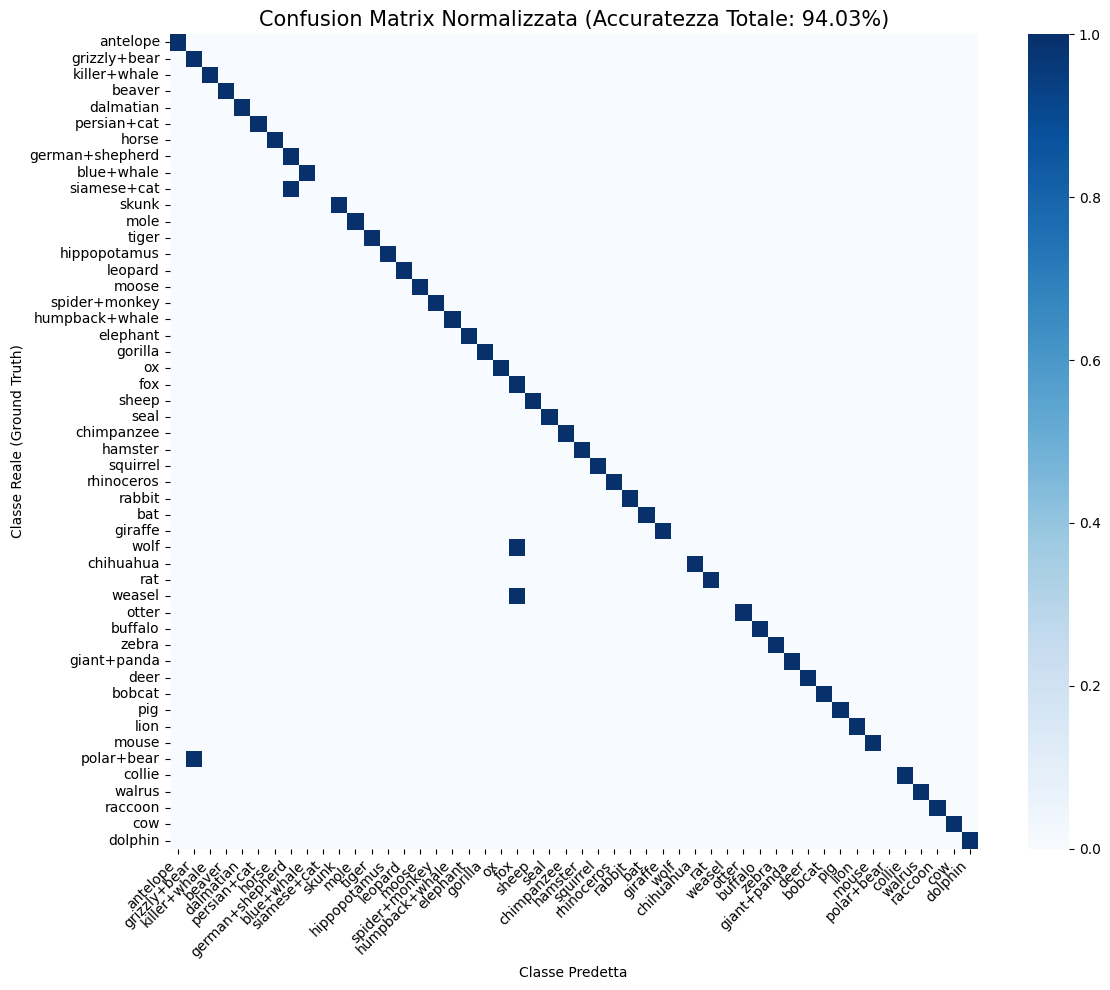


Analisi degli Errori Principali:
 - 174 volte: 'polar+bear' è stato scambiato per 'grizzly+bear'
 - 118 volte: 'wolf' è stato scambiato per 'fox'
 - 100 volte: 'siamese+cat' è stato scambiato per 'german+shepherd'
 - 54 volte: 'weasel' è stato scambiato per 'fox'


In [30]:
plot_test_results(accuracy, preds, labels, class_names=classes)

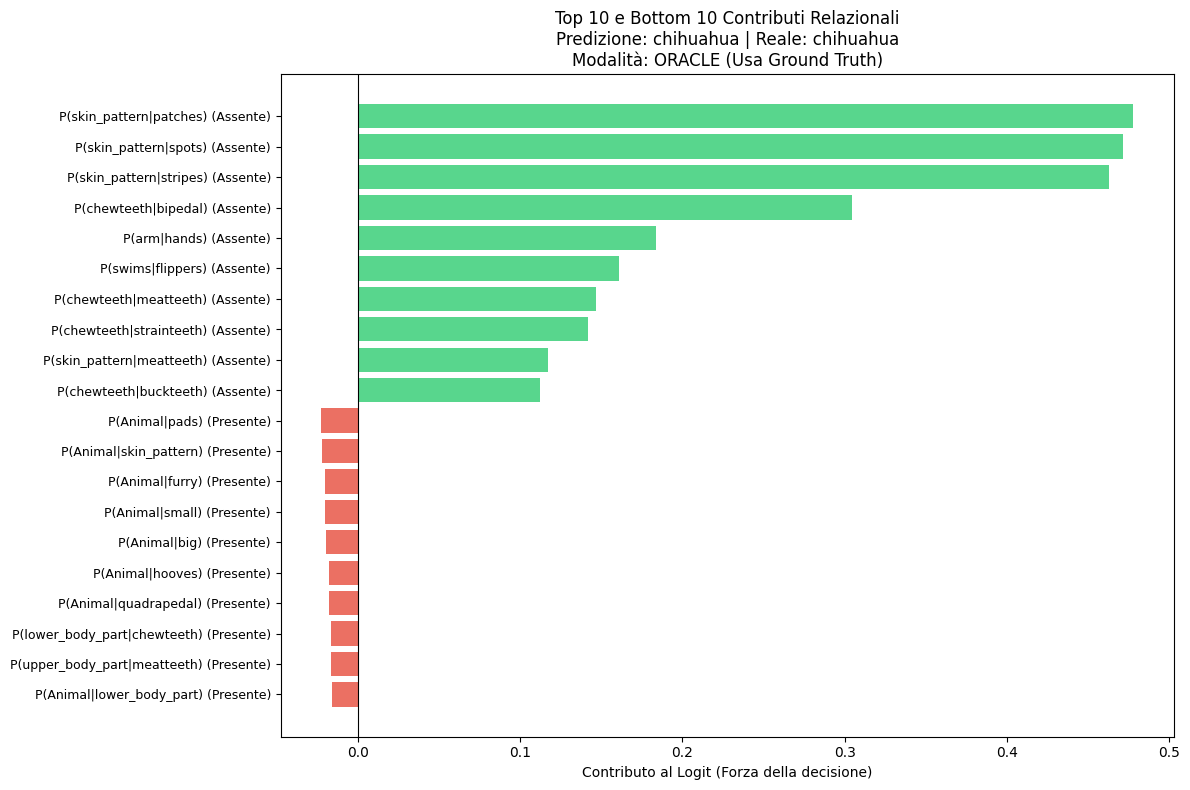

True

In [31]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_model, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors, 
    info_type=info, 
    target_class="chihuahua", 
    bipolar=bipolar
)

### CBM standard

In [32]:
info = "concepts"
c_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(c_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
c_history = train_cbm_classifier(
    c_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=1.595, Acc=79.5% | VAL: Loss=0.517, Acc=98.1%
Epoca   3/20 | TRAIN: Loss=0.293, Acc=99.2% | VAL: Loss=0.163, Acc=100.0%
Epoca   4/20 | TRAIN: Loss=0.112, Acc=100.0% | VAL: Loss=0.076, Acc=100.0%
Epoca   5/20 | TRAIN: Loss=0.057, Acc=100.0% | VAL: Loss=0.042, Acc=100.0%
Epoca   6/20 | TRAIN: Loss=0.033, Acc=100.0% | VAL: Loss=0.025, Acc=100.0%
Epoca   7/20 | TRAIN: Loss=0.020, Acc=100.0% | VAL: Loss=0.016, Acc=100.0%
Epoca   8/20 | TRAIN: Loss=0.013, Acc=100.0% | VAL: Loss=0.010, Acc=100.0%
Epoca   9/20 | TRAIN: Loss=0.008, Acc=100.0% | VAL: Loss=0.007, Acc=100.0%
Epoca  10/20 | TRAIN: Loss=0.006, Acc=100.0% | VAL: Loss=0.005, Acc=100.0%
Epoca  11/20 | TRAIN: Loss=0.004, Acc=100.0% | VAL: Loss=0.003, Acc=100.0%
Epoca  12/20 | TRAIN: Loss=0.003, Acc=100.0% | VAL: Loss=0.002, Acc=100.0%
Epoca  13/20 | TRAIN: Loss=0.002, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca  14/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL:

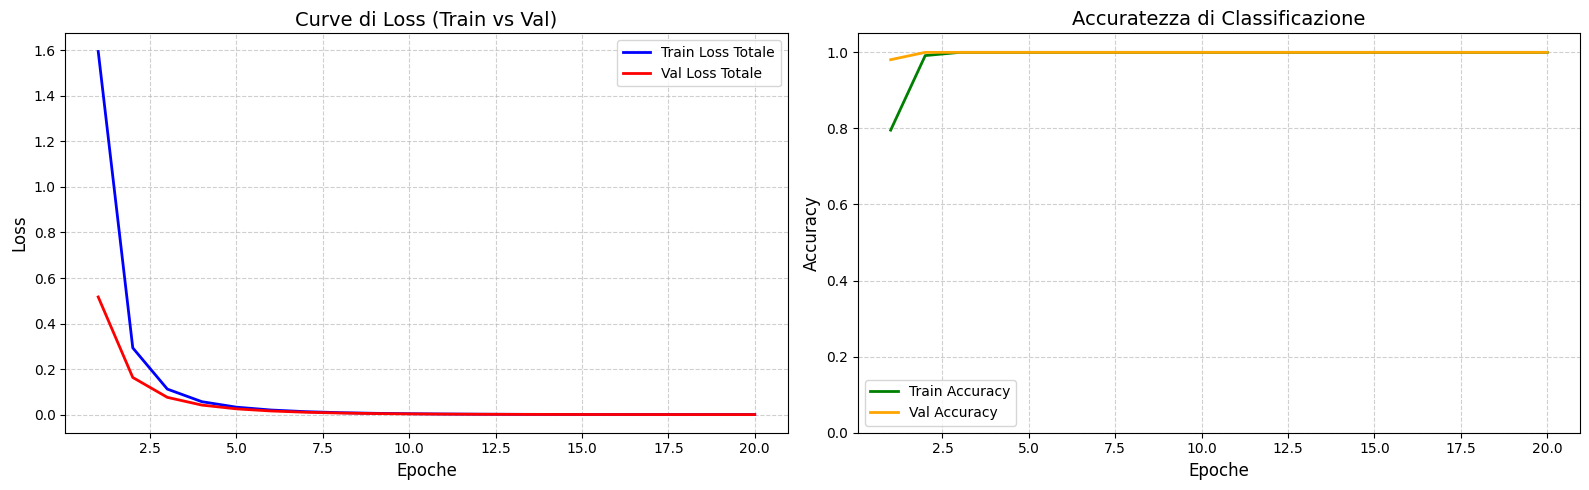

In [33]:
from src.CHM.train import plot_history
plot_history(c_history)

In [34]:
accuracy, preds, labels = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     oracle=True,
)

Inizio valutazione sul Test Set...

Risultati Test Set:
Accuratezza Totale: 100.00% (7465/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       209
           1       1.00      1.00      1.00       170
           2       1.00      1.00      1.00        58
           3       1.00      1.00      1.00        38
           4       1.00      1.00      1.00       110
           5       1.00      1.00      1.00       149
           6       1.00      1.00      1.00       329
           7       1.00      1.00      1.00       207
           8       1.00      1.00      1.00        35
           9       1.00      1.00      1.00       100

   micro avg       1.00      1.00      1.00      1405
   macro avg       1.00      1.00      1.00      1405
weighted avg       1.00      1.00      1.00      1405



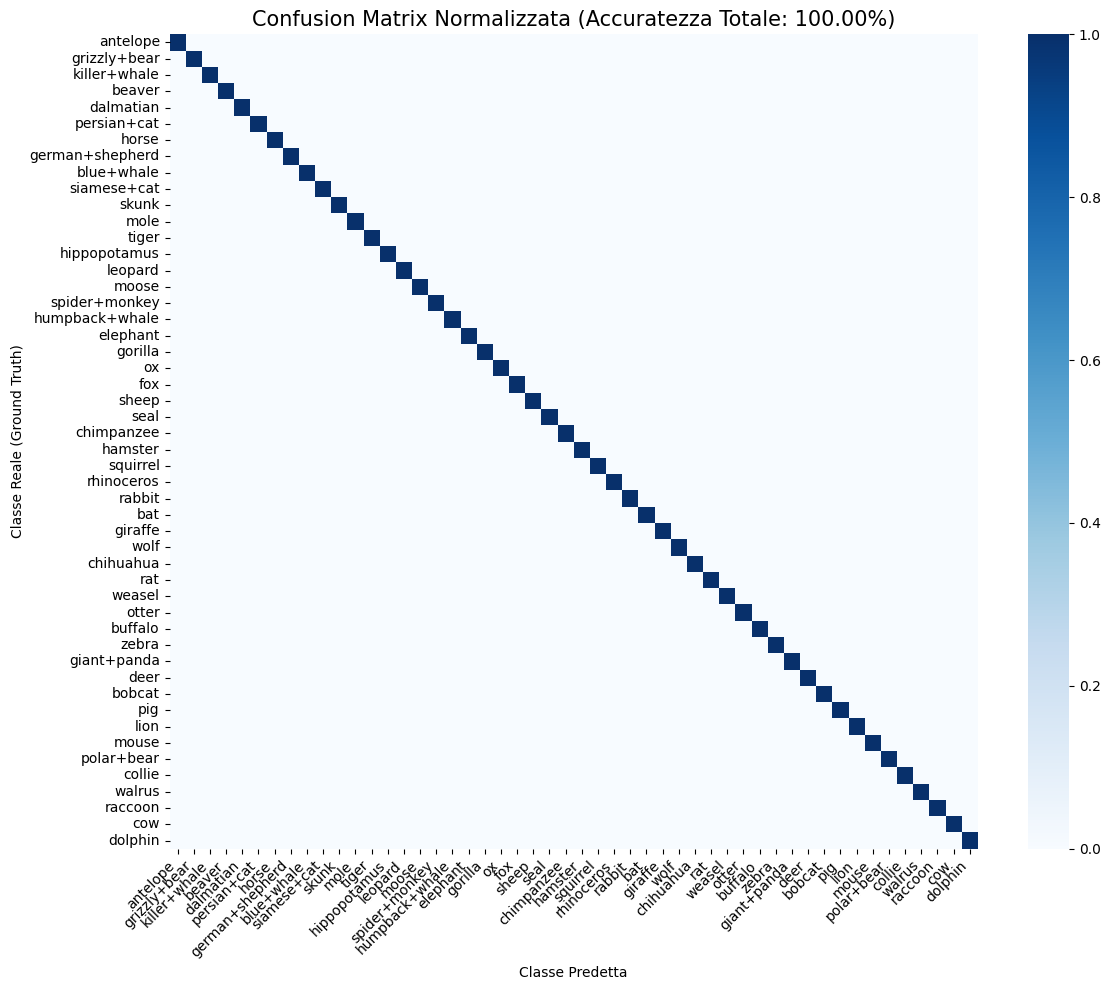


Analisi degli Errori Principali:


In [35]:
plot_test_results(accuracy, preds, labels, class_names=classes)

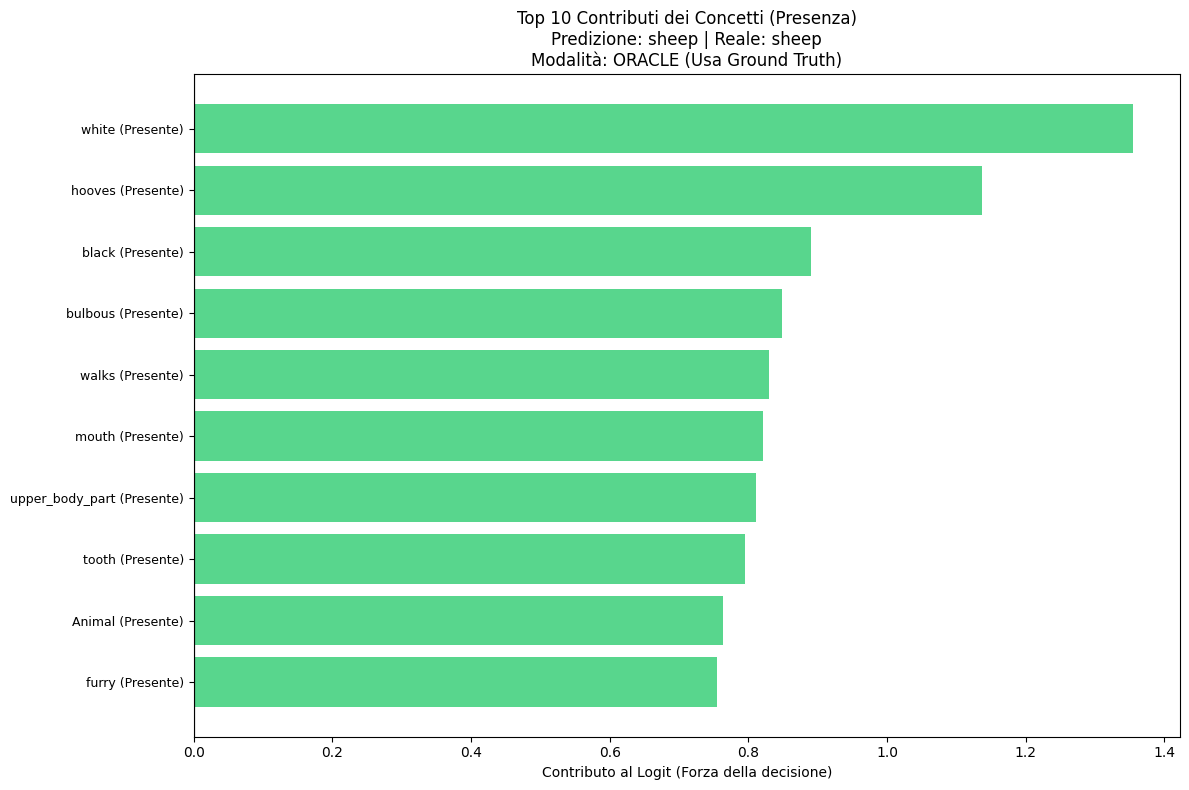

True

In [36]:
from src.CHM.interpretation import explain_prediction

explain_prediction(c_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, info_type=info)

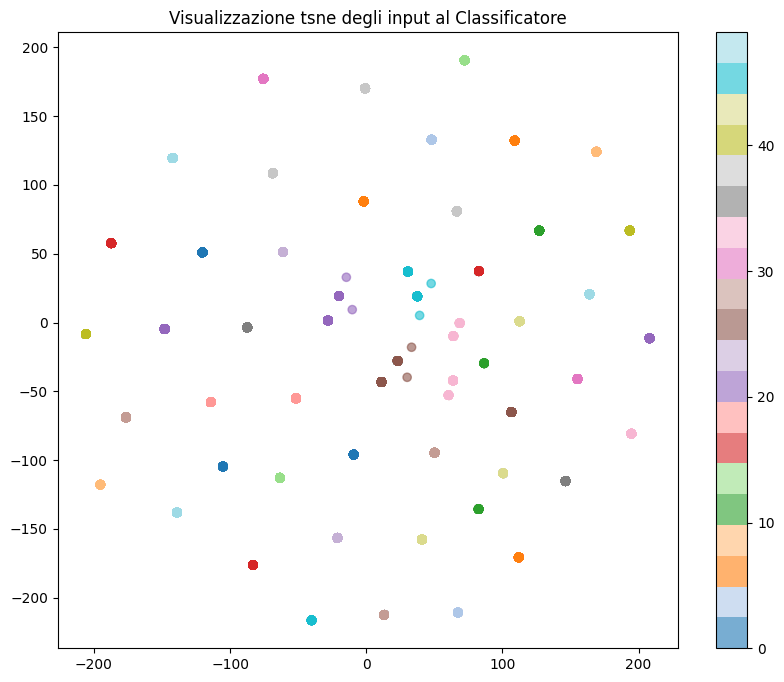

In [37]:
from src.CHM.interpretation import visualizza_separabilita, shuffle_test

visualizza_separabilita(
    model=c_model,
    test_dataloader=test_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    info=info,
    bipolar=bipolar,
    projection_method='tsne'
)

## NEXT

1. controllare 100% accuracy sospetto
2. valutare istanza per istanza interpretazione
3. training x -> c_pred

## Concept Predictor

In [38]:
from src.CHM.model import ConceptPredictor

concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(concept_predictor.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [39]:
from src.CHM.train import train_concept_predictor

history = train_concept_predictor(
    concept_predictor, 
    train_dataloader, 
    val_dataloader, 
    class_concept_matrix, 
    optimizer, 
    criterion, 
    EPOCHS, 
    device
)

Loss: 3.5541 | Acc: 95.9588 || Val Loss: 2.6028 | Val Acc: 96.9724
Loss: 2.2488 | Acc: 97.4222 || Val Loss: 2.3636 | Val Acc: 97.2119
Loss: 1.9616 | Acc: 97.7455 || Val Loss: 2.2181 | Val Acc: 97.4021
Loss: 1.7839 | Acc: 97.9245 || Val Loss: 2.1708 | Val Acc: 97.4964
Loss: 1.6640 | Acc: 98.0744 || Val Loss: 2.2056 | Val Acc: 97.4492
Loss: 1.5721 | Acc: 98.1699 || Val Loss: 2.1594 | Val Acc: 97.4910
Loss: 1.4948 | Acc: 98.2686 || Val Loss: 2.1068 | Val Acc: 97.5682
Loss: 1.4371 | Acc: 98.3339 || Val Loss: 2.1304 | Val Acc: 97.5644
Loss: 1.3837 | Acc: 98.4106 || Val Loss: 2.1905 | Val Acc: 97.4953
Loss: 1.3338 | Acc: 98.4531 || Val Loss: 2.2410 | Val Acc: 97.4551
Loss: 1.2993 | Acc: 98.4887 || Val Loss: 2.2064 | Val Acc: 97.4921
Loss: 1.2697 | Acc: 98.5332 || Val Loss: 2.2244 | Val Acc: 97.5028
Loss: 1.2398 | Acc: 98.5674 || Val Loss: 2.2015 | Val Acc: 97.5698
Loss: 1.2137 | Acc: 98.5922 || Val Loss: 2.2788 | Val Acc: 97.4755
Loss: 1.1827 | Acc: 98.6296 || Val Loss: 2.2789 | Val Acc: 97.

In [40]:
info = "boxes"
b_accuracy, b_preds, b_labels = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Risultati Test Set:
Accuratezza Totale: 90.02% (6720/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       209
           1       0.89      0.91      0.90       170
           2       0.82      0.79      0.81        58
           3       0.69      0.82      0.75        38
           4       0.96      0.98      0.97       110
           5       0.92      0.96      0.94       149
           6       0.98      0.91      0.95       329
           7       0.91      0.83      0.87       207
           8       0.57      0.23      0.33        35
           9       0.82      0.80      0.81       100

   micro avg       0.90      0.88      0.89      1405
   macro avg       0.84      0.81      0.82      1405
weighted avg       0.90      0.88      0.88      1405



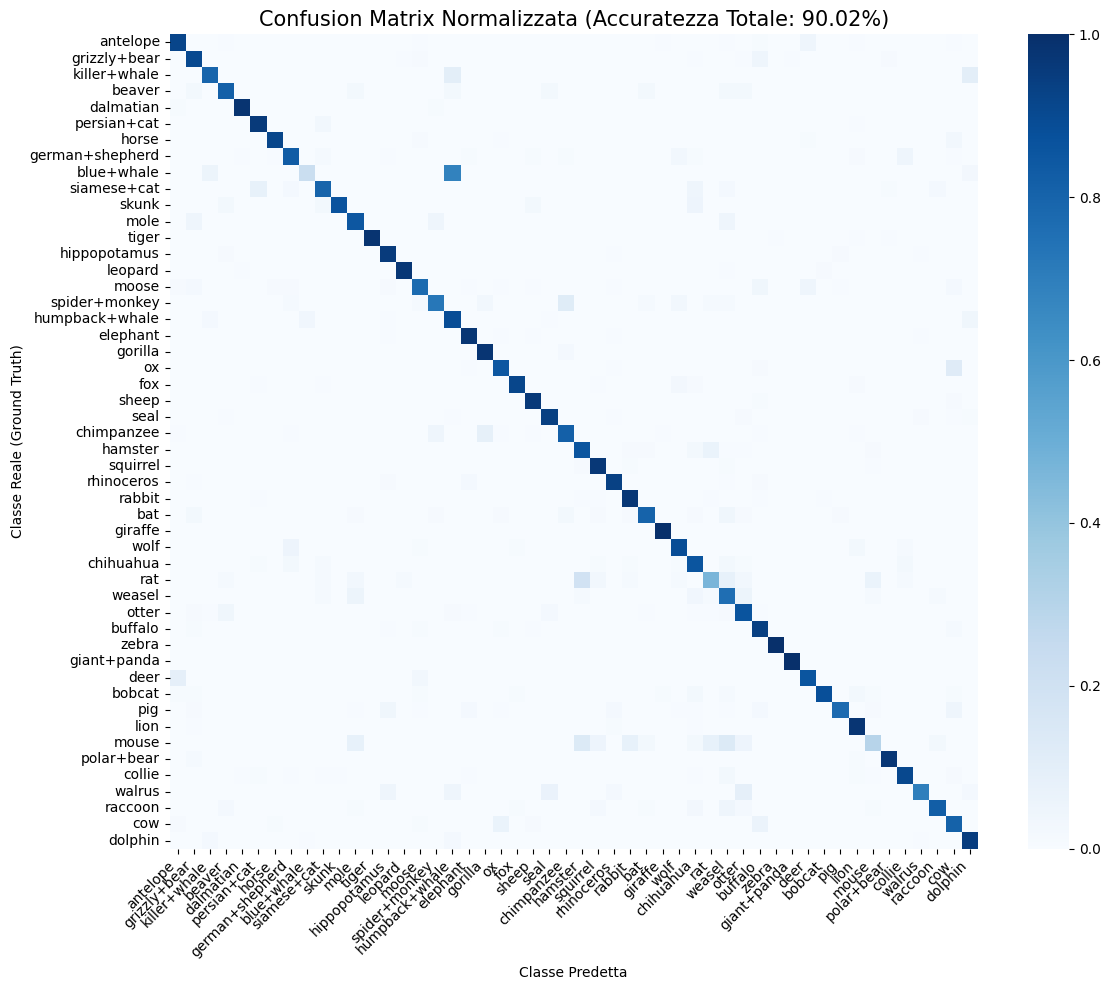


Analisi degli Errori Principali:
 - 25 volte: 'deer' è stato scambiato per 'antelope'
 - 24 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 18 volte: 'ox' è stato scambiato per 'cow'
 - 17 volte: 'cow' è stato scambiato per 'ox'
 - 16 volte: 'cow' è stato scambiato per 'buffalo'


In [41]:
plot_test_results(b_accuracy, b_preds, b_labels, class_names=classes)

In [42]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Risultati Test Set:
Accuratezza Totale: 43.32% (3234/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       209
           1       1.00      0.38      0.55       170
           2       0.54      0.55      0.55        58
           3       1.00      0.05      0.10        38
           4       0.97      0.92      0.94       110
           5       0.00      0.00      0.00       149
           6       1.00      0.66      0.79       329
           7       0.93      0.82      0.87       207
           8       0.00      0.00      0.00        35
           9       0.19      0.94      0.31       100

   micro avg       0.60      0.48      0.54      1405
   macro avg       0.56      0.43      0.41      1405
weighted avg       0.63      0.48      0.50      1405



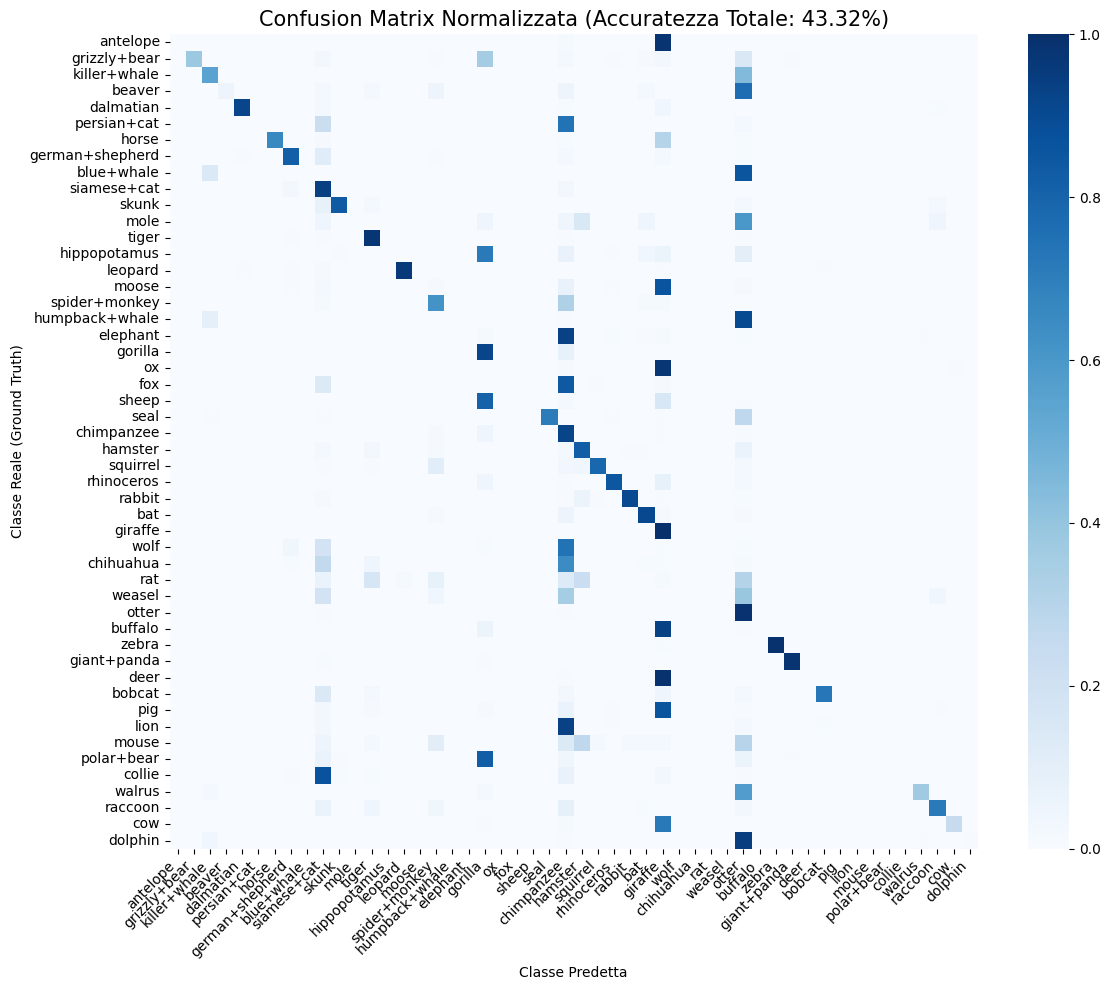


Analisi degli Errori Principali:
 - 266 volte: 'deer' è stato scambiato per 'giraffe'
 - 229 volte: 'sheep' è stato scambiato per 'gorilla'
 - 205 volte: 'antelope' è stato scambiato per 'giraffe'
 - 194 volte: 'elephant' è stato scambiato per 'chimpanzee'
 - 193 volte: 'cow' è stato scambiato per 'giraffe'


In [43]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

In [44]:
info = "concepts"
c_accuracy, c_preds, c_labels = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Risultati Test Set:
Accuratezza Totale: 90.05% (6722/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       209
           1       0.91      0.90      0.90       170
           2       0.85      0.78      0.81        58
           3       0.76      0.82      0.78        38
           4       0.96      0.98      0.97       110
           5       0.90      0.97      0.93       149
           6       0.97      0.92      0.95       329
           7       0.91      0.84      0.87       207
           8       0.57      0.23      0.33        35
           9       0.84      0.79      0.81       100

   micro avg       0.90      0.88      0.89      1405
   macro avg       0.85      0.81      0.82      1405
weighted avg       0.89      0.88      0.89      1405



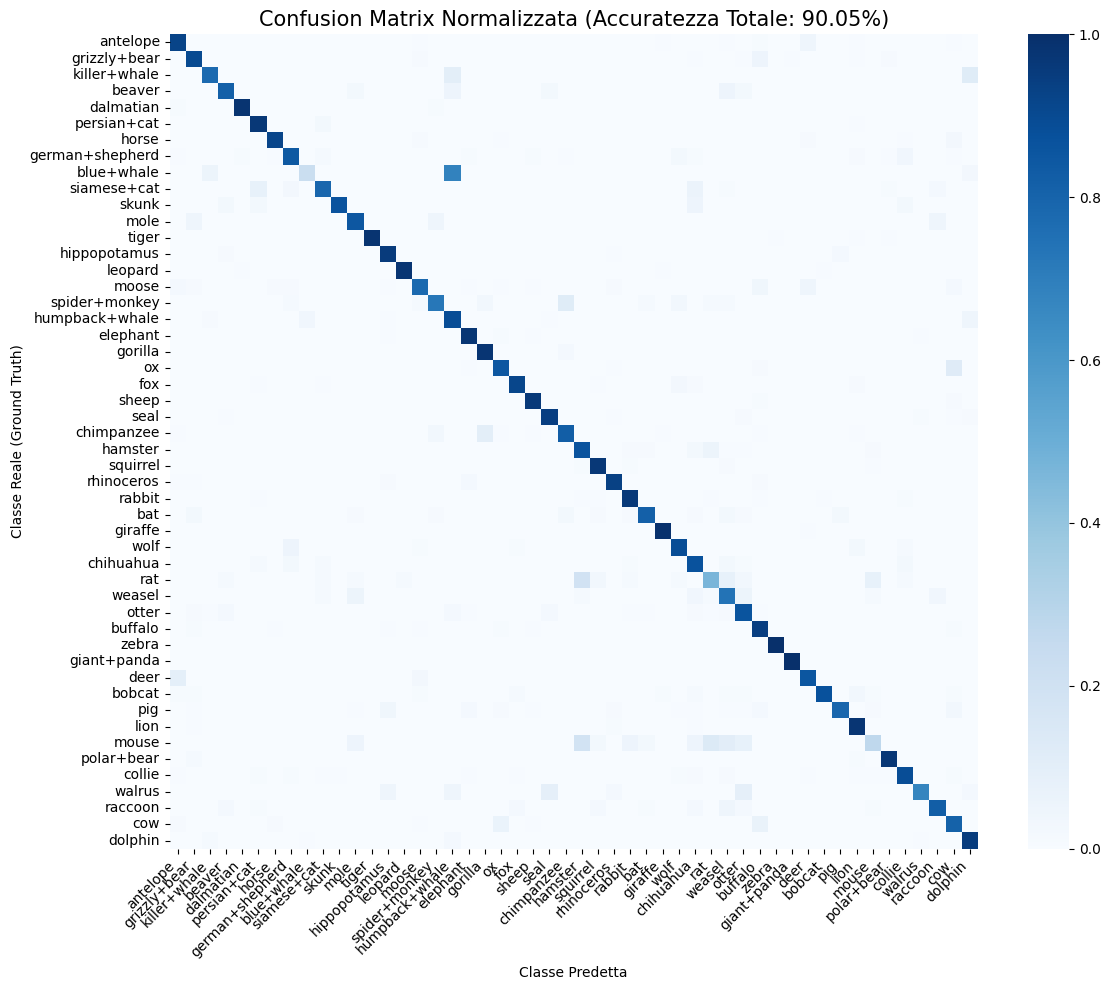


Analisi degli Errori Principali:
 - 26 volte: 'deer' è stato scambiato per 'antelope'
 - 24 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 19 volte: 'cow' è stato scambiato per 'buffalo'
 - 18 volte: 'ox' è stato scambiato per 'cow'
 - 17 volte: 'cow' è stato scambiato per 'ox'


In [45]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)